## Pós em Engenharia de Software
### MVP - Treinamento de Modelo de Machine Learning para Classificação
### Vinicius Pereira da Silva

Neste notebook, foi desenvolvido um modelo de machine learning para prever a variável `DEATH_EVENT`, utilizando um problema de classificação binária com base no dataset Heart Failure Clinical Records.

As etapas contempladas neste trabalho incluem:
- carga e análise inicial dos dados;
- separação em treino e teste com holdout;
- transformação de dados;
- treinamento com os algoritmos KNN, Árvore de Decisão, Naive Bayes e SVM;
- otimização de hiperparâmetros;
- avaliação e comparação dos modelos;
- exportação do modelo final.

## Importação das dependências

Nesta etapa, são importadas as bibliotecas necessárias para leitura dos dados, pré-processamento, treinamento, avaliação e exportação do modelo.

In [2]:
# configuração para não exibir os warnings
import warnings

warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import joblib

## Funções utilitárias

In [18]:
def exec_grid_search(model, pipelines, param_grid, X_train, y_train, cv, scoring="accuracy"):
    best_results = []
    for name, model in pipelines:
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_results.append({
            "Algoritmo": name,
            "Pipeline": model,
            "Melhor Score CV": round(grid.best_score_, 4),
            "Melhores Parâmetros": grid.best_params_
        })
        print(f"{name} | {model}")
        print(f"Melhor score: {grid.best_score_:.4f}")
        print(f"Melhores parâmetros: {grid.best_params_}")
        print("-" * 60)
    return best_results

### Carga do dataset
Dataset em uso: [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)

Foi utilizado o dataset Heart Failure Clinical Records, contendo informações clínicas de pacientes e a variável alvo `DEATH_EVENT`, que indica se o paciente veio a óbito durante o período analisado.

In [3]:
# Informa a URL do csv para importação
url = "https://raw.githubusercontent.com/viniciuspdasilva-dev/projeto_mvp_pos_sprint/refs/heads/main/heart_failure_clinical_records_dataset.csv"

# Lê o arquivo
df = pd.read_csv(url, delimiter=',')

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Analise exploratória dos dados do dataset

Nesta etapa, foi realizada uma inspeção inicial do dataset para verificar:
- quantidade de registros e atributos;
- tipos de dados;
- existência de valores ausentes;
- distribuição da variável alvo.

Essa análise é importante para entender a qualidade dos dados e orientar as etapas seguintes de modelagem.

Dimensões do dataset: (299, 13)

Tipos de dados:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Valores ausentes por coluna:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Distribuição da variável alvo:
DEAT

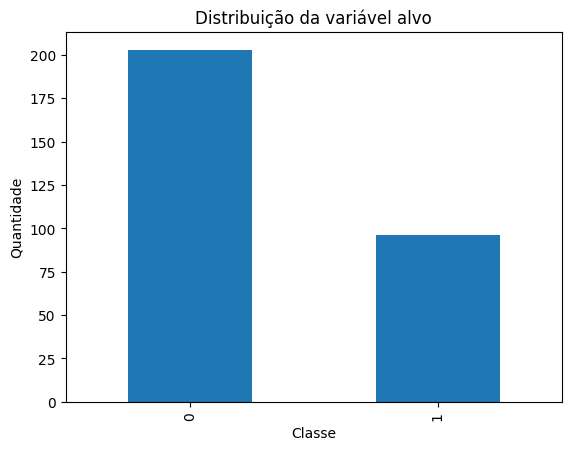

In [4]:
print("Dimensões do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

print("\nDistribuição da variável alvo:")
print(df["DEATH_EVENT"].value_counts())
print(df["DEATH_EVENT"].value_counts(normalize=True))

print(df.describe())

df["DEATH_EVENT"].value_counts().plot(kind="bar")
plt.title("Distribuição da variável alvo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()



### Separação em conjunto de treino e conjunto de teste com holdout

Os dados foram divididos em 80% para treino e 20% para teste, utilizando holdout com estratificação, de forma a preservar a proporção das classes em ambos os conjuntos.

In [5]:
test_size = 0.20  # tamanho do conjunto de teste
seed = 10  # semente aleatória

# Separação em conjuntos de treino e teste

X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_size,
    shuffle=True,
    random_state=seed,
    stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (239, 12) (239,)
Teste: (60, 12) (60,)


## Estratégia de validação

Para avaliar os modelos de forma mais robusta, foi utilizada validação cruzada estratificada com 10 partições.

In [6]:
# holdout com estratificação
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(
    n_splits=num_particoes,
    shuffle=True,
    random_state=seed
)  # Validação cruzada


## Modelagem e Inferêrencia

## Criação e avaliação de modelos

## Treinamento inicial dos modelos

Foram treinados quatro algoritmos clássicos de classificação:
- KNN
- Árvore de Decisão
- Naive Bayes
- SVM

Inicialmente, os modelos foram avaliados sem transformação de escala para estabelecer uma linha de base.


KNN: média=0.6112 desvio=0.0571
CART: média=0.7486 desvio=0.0927
NB: média=0.7864 desvio=0.0445
SVM: média=0.6779 desvio=0.0175


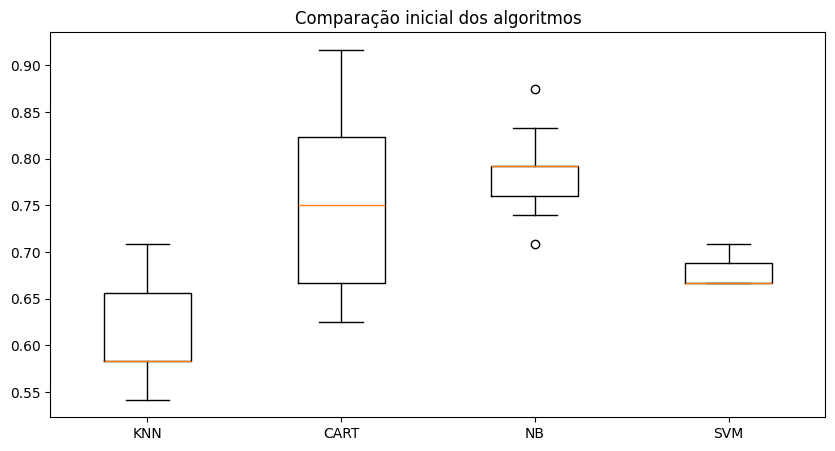

In [8]:
np.random.seed(seed)

models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Listas para armazenar os resultados
results = []
names = []

for name, model in models:
    cv_res = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_res)
    names.append(name)
    print(f"{name}: média={cv_res.mean():.4f} desvio={cv_res.std():.4f}")

plt.figure(figsize=(10, 5))
plt.boxplot(results, labels=names)
plt.title("Comparação inicial dos algoritmos")
plt.show()

### Criação e avaliação de modelos: dados padronizados e normalizados

Nesta etapa, foram avaliadas abordagens com:
- dados originais;
- dados padronizados com StandardScaler;
- dados normalizados com MinMaxScaler.

Isso foi feito porque algoritmos como KNN e SVM são sensíveis à escala dos atributos.



KNN-orig: média=0.6112 desvio=0.0571
CART-orig: média=0.7319 desvio=0.1115
NB-orig: média=0.7864 desvio=0.0445
SVM-orig: média=0.6779 desvio=0.0175
KNN-padr: média=0.7319 desvio=0.0613
CART-padr: média=0.7444 desvio=0.1006
NB-padr: média=0.7696 desvio=0.0484
SVM-padr: média=0.8069 desvio=0.0842
KNN-norm: média=0.6652 desvio=0.0647
CART-norm: média=0.7569 desvio=0.0979
NB-norm: média=0.7696 desvio=0.0484
SVM-norm: média=0.7946 desvio=0.0700


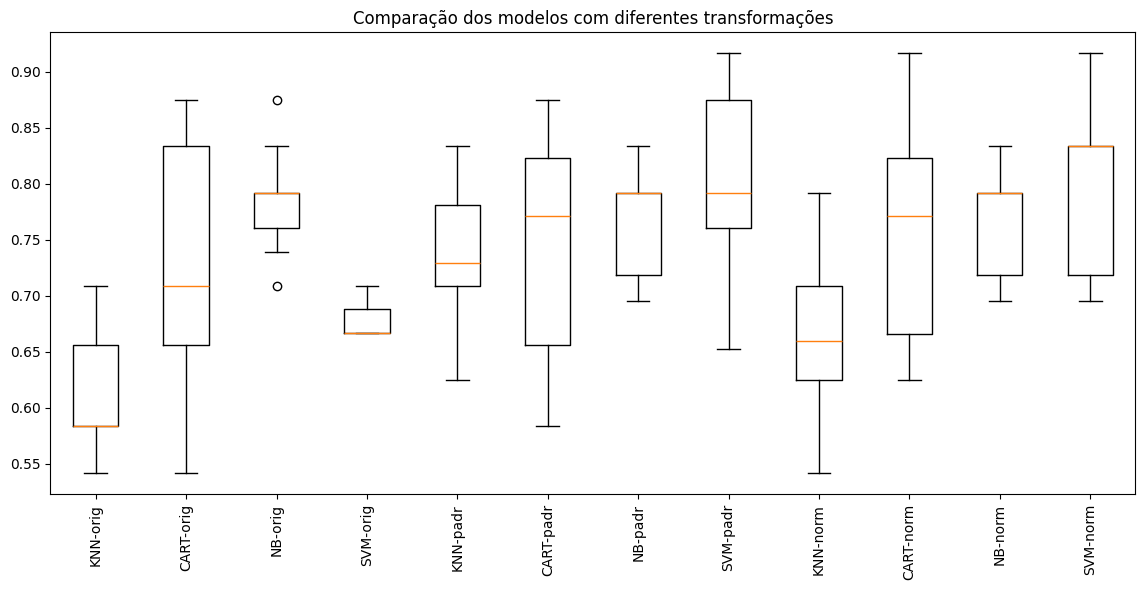

In [11]:
np.random.seed(7)

pipelines = []
results = []
names = []

# Criando os elementos do pipeline

# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))

# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: média={cv_results.mean():.4f} desvio={cv_results.std():.4f}")

# Boxplot de comparação dos modelos
plt.figure(figsize=(14, 6))
plt.boxplot(results, labels=names)
plt.xticks(rotation=90)
plt.title("Comparação dos modelos com diferentes transformações")
plt.show()

### Otimização de hiperparâmetros

Neste experimento, avaliamos diferentes algoritmos de classificação (SVM, GaussianNB e KNN)
com diversas estratégias de pré-processamento (StandardScaler, MinMaxScaler, RobustScaler, Normalizer).
O objetivo é identificar a melhor combinação de hiperparâmetros e tratamento dos dados.

In [20]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

resultados_grid = []
np.random.seed(7)

### KNN - KNeighborsClassifier

In [21]:
pipelines_knn = [
    ("KNN-orig", Pipeline([
        ("model", KNeighborsClassifier())
    ])),
    ("KNN-padr", Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])),
    ("KNN-norm", Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", KNeighborsClassifier())
    ])),
    ("KNN-robust", Pipeline([
        ("scaler", RobustScaler()),
        ("model", KNeighborsClassifier())
    ])),
    ("KNN-unit", Pipeline([
        ("scaler", Normalizer()),
        ("model", KNeighborsClassifier())
    ])),
]
param_grid_knn = {
    "model__n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    "model__metric": ["euclidean", "manhattan", "minkowski"]
}
resultados_grid.extend(
    exec_grid_search("KNN", pipelines_knn, param_grid_knn, X_train, y_train, kfold)
)

KNN-orig | Pipeline(steps=[('model', KNeighborsClassifier())])
Melhor score: 0.6821
Melhores parâmetros: {'model__metric': 'euclidean', 'model__n_neighbors': 15}
------------------------------------------------------------
KNN-padr | Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])
Melhor score: 0.7737
Melhores parâmetros: {'model__metric': 'manhattan', 'model__n_neighbors': 13}
------------------------------------------------------------
KNN-norm | Pipeline(steps=[('scaler', MinMaxScaler()), ('model', KNeighborsClassifier())])
Melhor score: 0.7569
Melhores parâmetros: {'model__metric': 'manhattan', 'model__n_neighbors': 13}
------------------------------------------------------------
KNN-robust | Pipeline(steps=[('scaler', RobustScaler()), ('model', KNeighborsClassifier())])
Melhor score: 0.7571
Melhores parâmetros: {'model__metric': 'euclidean', 'model__n_neighbors': 19}
------------------------------------------------------------
KNN-

### DecisionTreeClassifier

In [23]:
pipelines_tree = [
    ("TREE-orig", Pipeline([
        ("model", DecisionTreeClassifier(random_state=10))
    ])),
    ("TREE-padr", Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(random_state=10))
    ])),
    ("TREE-norm", Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", DecisionTreeClassifier(random_state=10))
    ])),
    ("TREE-robust", Pipeline([
        ("scaler", RobustScaler()),
        ("model", DecisionTreeClassifier(random_state=10))
    ])),
    ("TREE-unit", Pipeline([
        ("scaler", Normalizer()),
        ("model", DecisionTreeClassifier(random_state=10))
    ])),
]

param_grid_tree = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

resultados_grid.extend(
    exec_grid_search("Decision Tree", pipelines_tree, param_grid_tree, X_train, y_train, kfold)
)

TREE-orig | Pipeline(steps=[('model', DecisionTreeClassifier(random_state=10))])
Melhor score: 0.8033
Melhores parâmetros: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
------------------------------------------------------------
TREE-padr | Pipeline(steps=[('scaler', StandardScaler()),
                ('model', DecisionTreeClassifier(random_state=10))])
Melhor score: 0.8033
Melhores parâmetros: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
------------------------------------------------------------
TREE-norm | Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model', DecisionTreeClassifier(random_state=10))])
Melhor score: 0.8033
Melhores parâmetros: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
------------------------------------------------------------
TREE-robus

## Naive Bayes

In [24]:
pipelines_nb = [
    ("NB-orig", Pipeline([
        ("model", GaussianNB())
    ])),
    ("NB-padr", Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ])),
    ("NB-norm", Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", GaussianNB())
    ])),
    ("NB-robust", Pipeline([
        ("scaler", RobustScaler()),
        ("model", GaussianNB())
    ])),
    ("NB-unit", Pipeline([
        ("scaler", Normalizer()),
        ("model", GaussianNB())
    ])),
]

param_grid_nb = {
    "model__var_smoothing": np.logspace(0, -9, num=50)
}

resultados_grid.extend(
    exec_grid_search("Naive Bayes", pipelines_nb, param_grid_nb, X_train, y_train, kfold)
)

NB-orig | Pipeline(steps=[('model', GaussianNB())])
Melhor score: 0.7991
Melhores parâmetros: {'model__var_smoothing': np.float64(3.556480306223121e-09)}
------------------------------------------------------------
NB-padr | Pipeline(steps=[('scaler', StandardScaler()), ('model', GaussianNB())])
Melhor score: 0.7739
Melhores parâmetros: {'model__var_smoothing': np.float64(0.022229964825261943)}
------------------------------------------------------------
NB-norm | Pipeline(steps=[('scaler', MinMaxScaler()), ('model', GaussianNB())])
Melhor score: 0.7741
Melhores parâmetros: {'model__var_smoothing': np.float64(0.07906043210907697)}
------------------------------------------------------------
NB-robust | Pipeline(steps=[('scaler', RobustScaler()), ('model', GaussianNB())])
Melhor score: 0.7739
Melhores parâmetros: {'model__var_smoothing': np.float64(0.0007543120063354615)}
------------------------------------------------------------
NB-unit | Pipeline(steps=[('scaler', Normalizer()), ('m

## SVM

In [25]:
pipelines_svm = [
    ("SVM-padr", Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ])),
    ("SVM-norm", Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", SVC())
    ])),
    ("SVM-robust", Pipeline([
        ("scaler", RobustScaler()),
        ("model", SVC())
    ])),
    ("SVM-unit", Pipeline([
        ("scaler", Normalizer()),
        ("model", SVC())
    ])),
]

param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

resultados_grid.extend(
    exec_grid_search("SVM", pipelines_svm, param_grid_svm, X_train, y_train, kfold)
)

SVM-padr | Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC())])
Melhor score: 0.8281
Melhores parâmetros: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
------------------------------------------------------------
SVM-norm | Pipeline(steps=[('scaler', MinMaxScaler()), ('model', SVC())])
Melhor score: 0.8408
Melhores parâmetros: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
------------------------------------------------------------
SVM-robust | Pipeline(steps=[('scaler', RobustScaler()), ('model', SVC())])
Melhor score: 0.8281
Melhores parâmetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
------------------------------------------------------------
SVM-unit | Pipeline(steps=[('scaler', Normalizer()), ('model', SVC())])
Melhor score: 0.6779
Melhores parâmetros: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
------------------------------------------------------------


## Resultados do comparativo

      Algoritmo                                           Pipeline  \
0      KNN-norm           (MinMaxScaler(), KNeighborsClassifier())   
1      KNN-orig                           (KNeighborsClassifier())   
2      KNN-padr         (StandardScaler(), KNeighborsClassifier())   
3    KNN-robust           (RobustScaler(), KNeighborsClassifier())   
4      KNN-unit             (Normalizer(), KNeighborsClassifier())   
5       NB-norm                     (MinMaxScaler(), GaussianNB())   
6       NB-orig                                     (GaussianNB())   
7       NB-padr                   (StandardScaler(), GaussianNB())   
8     NB-robust                     (RobustScaler(), GaussianNB())   
9       NB-unit                       (Normalizer(), GaussianNB())   
10     SVM-norm                            (MinMaxScaler(), SVC())   
11     SVM-padr                          (StandardScaler(), SVC())   
12   SVM-robust                            (RobustScaler(), SVC())   
13     SVM-unit     

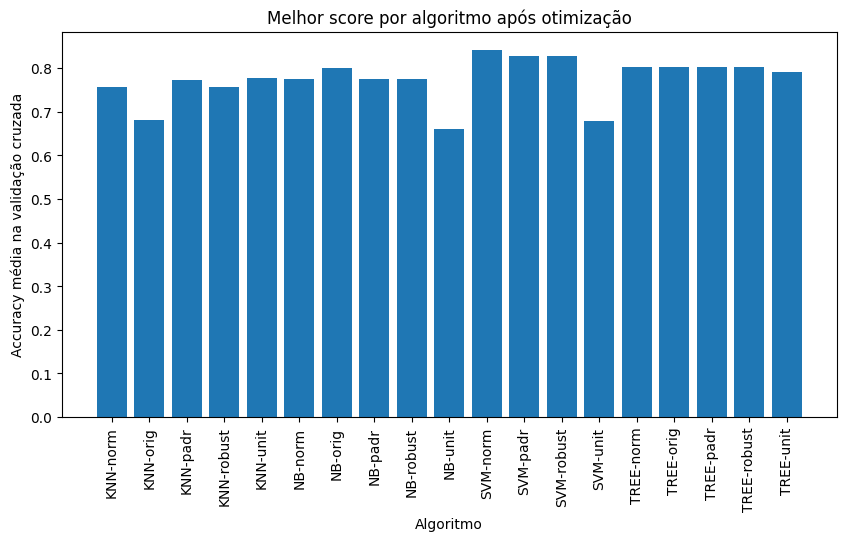

In [33]:
df_grid = pd.DataFrame(resultados_grid)

df_melhores = (
    df_grid
    .sort_values(by="Melhor Score CV", ascending=False)
    .groupby("Algoritmo", as_index=False)
    .first()
)

print(df_melhores)
plt.figure(figsize=(10, 5))
plt.bar(df_melhores["Algoritmo"], df_melhores["Melhor Score CV"])
plt.title("Melhor score por algoritmo após otimização")
plt.ylabel("Accuracy média na validação cruzada")
plt.xlabel("Algoritmo")
plt.xticks(rotation=90)
plt.show()

In [36]:
print("Tabela com os melhores modelos por algoritmo:")
display(df_melhores)

print("\nMelhor algoritmo geral:")
print(f"Algoritmo: {melhor_global['Algoritmo']}")
print(f"Pipeline: {melhor_global['Pipeline']}")
print(f"Score: {melhor_global['Melhor Score CV']}")
print(f"Hiperparâmetros: {melhor_global['Melhores Parâmetros']}")

Tabela com os melhores modelos por algoritmo:


,Algoritmo,Pipeline,Melhor Score CV,Melhores Parâmetros
0,KNN-norm,"(MinMaxScaler(), KNeighborsClassifier())",0.7569,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,KNN-orig,(KNeighborsClassifier()),0.6821,"{'model__metric': 'euclidean', 'model__n_neigh..."
2,KNN-padr,"(StandardScaler(), KNeighborsClassifier())",0.7737,"{'model__metric': 'manhattan', 'model__n_neigh..."
3,KNN-robust,"(RobustScaler(), KNeighborsClassifier())",0.7571,"{'model__metric': 'euclidean', 'model__n_neigh..."
4,KNN-unit,"(Normalizer(), KNeighborsClassifier())",0.7781,"{'model__metric': 'manhattan', 'model__n_neigh..."
5,NB-norm,"(MinMaxScaler(), GaussianNB())",0.7741,{'model__var_smoothing': 0.07906043210907697}
6,NB-orig,(GaussianNB()),0.7991,{'model__var_smoothing': 3.556480306223121e-09}
7,NB-padr,"(StandardScaler(), GaussianNB())",0.7739,{'model__var_smoothing': 0.022229964825261943}
8,NB-robust,"(RobustScaler(), GaussianNB())",0.7739,{'model__var_smoothing': 0.0007543120063354615}
9,NB-unit,"(Normalizer(), GaussianNB())",0.6612,{'model__var_smoothing': 1.0}



Melhor algoritmo geral:
Algoritmo: SVM-norm
Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()), ('model', SVC())])
Score: 0.8408
Hiperparâmetros: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


## Análise dos resultados

A etapa de otimização de hiperparâmetros permitiu identificar, para cada algoritmo, a combinação mais adequada de parâmetros e estratégia de pré-processamento.

Observou-se que:
- algoritmos baseados em distância, como KNN, apresentaram sensibilidade à transformação da escala dos dados;
- o SVM apresentou melhor desempenho com normalização MinMaxScaler;
- o Naive Bayes apresentou desempenho competitivo mesmo sem transformações complexas;
- a Árvore de Decisão mostrou menor dependência de escalonamento, mas respondeu aos ajustes de profundidade e critérios de divisão.

Com isso, foi possível selecionar configurações mais robustas para a etapa seguinte de avaliação final no conjunto de teste.

### ML escolhido - hiperparametros e scaler
- **SVM** - MinMaxScaler (C=1, kernel=linear, gamma=scale)

## Finalização do modelo

In [41]:
# Avaliação do modelo com o conjunto de testes
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Preparação do modelo
scaler = MinMaxScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
model = SVC(C=1, kernel="linear", gamma="scale")
model.fit(rescaledX, y_train)

# Estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test)
predictions = model.predict(rescaledTestX)
print("Acurácia no teste: ", accuracy_score(y_test, predictions))
print("\nRelátorio de classificação:")
print(classification_report(y_test, predictions))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, predictions))


Acurácia no teste:  0.8333333333333334

Relátorio de classificação:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        41
           1       0.74      0.74      0.74        19

    accuracy                           0.83        60
   macro avg       0.81      0.81      0.81        60
weighted avg       0.83      0.83      0.83        60


Matriz de confusão:
[[36  5]
 [ 5 14]]


In [57]:
# Preparação do modelo com TODO o dataset
model = SVC(C=1, kernel="linear", gamma="scale", probability=True)
scaler = MinMaxScaler().fit(X)
rescaledX = scaler.transform(X)
model.fit(rescaledX, y)

SVC(C=1, kernel='linear', probability=True)

## Simulando com dados ficticios

In [58]:

np.random.seed(42)  # garante reprodutibilidade

data = {
    'age': np.random.randint(40, 95, size=30).tolist(),  # idade entre 40 e 94
    'anaemia': np.random.randint(0, 2, size=30).tolist(),  # binário
    'creatinine_phosphokinase': np.random.randint(23, 800, size=30).tolist(),  # níveis plausíveis
    'diabetes': np.random.randint(0, 2, size=30).tolist(),  # binário
    'ejection_fraction': np.random.randint(15, 60, size=30).tolist(),  # %
    'high_blood_pressure': np.random.randint(0, 2, size=30).tolist(),  # binário
    'platelets': np.random.randint(100000, 500000, size=30).tolist(),  # contagem de plaquetas
    'serum_creatinine': np.round(np.random.uniform(0.5, 5.0, size=30), 2).tolist(),  # mg/dL
    'serum_sodium': np.random.randint(120, 150, size=30).tolist(),  # mEq/L
    'sex': np.random.randint(0, 2, size=30).tolist(),  # binário
    'smoking': np.random.randint(0, 2, size=30).tolist(),  # binário
    'time': np.random.randint(1, 300, size=30).tolist(),  # dias
}
data

df_ficticio = pd.DataFrame(data)
df_ficticio.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,78,0,296,1,43,1,353618,1.96,120,1,0,131
1,91,1,410,1,29,1,345310,1.05,120,1,0,152
2,68,0,623,1,59,0,150015,2.10,138,0,1,54
3,54,0,338,1,15,0,348550,4.58,149,0,1,120
4,82,0,36,1,39,1,222096,1.72,121,1,0,161


In [59]:
array_entrada = df_ficticio.values
X_entrada = array_entrada[:, 0:12]

# Padronizacao nos dados usando o scaler
rescaledEntradaX = scaler.transform(X_entrada)
print(rescaledEntradaX)

[[6.90909091e-01 0.00000000e+00 3.48303139e-02 1.00000000e+00
  4.39393939e-01 1.00000000e+00 3.98251909e-01 1.64044944e-01
  2.00000000e-01 1.00000000e+00 0.00000000e+00 4.51957295e-01]
 [9.27272727e-01 1.00000000e+00 4.93748405e-02 1.00000000e+00
  2.27272727e-01 1.00000000e+00 3.88180386e-01 6.17977528e-02
  2.00000000e-01 1.00000000e+00 0.00000000e+00 5.26690391e-01]
 [5.09090909e-01 0.00000000e+00 7.65501403e-02 1.00000000e+00
  6.81818182e-01 0.00000000e+00 1.51430476e-01 1.79775281e-01
  7.14285714e-01 0.00000000e+00 1.00000000e+00 1.77935943e-01]
 [2.54545455e-01 0.00000000e+00 4.01888237e-02 1.00000000e+00
  1.51515152e-02 0.00000000e+00 3.92108134e-01 4.58426966e-01
  1.02857143e+00 0.00000000e+00 1.00000000e+00 4.12811388e-01]
 [7.63636364e-01 0.00000000e+00 1.65858637e-03 1.00000000e+00
  3.78787879e-01 1.00000000e+00 2.38811977e-01 1.37078652e-01
  2.28571429e-01 1.00000000e+00 0.00000000e+00 5.58718861e-01]
 [1.27272727e-01 0.00000000e+00 3.07476397e-02 1.00000000e+00
  1

In [60]:
saidas = model.predict(rescaledEntradaX)
print(saidas)

[0 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0]


## Salvando o modelo e scaler em arquivo

Após a escolha do melhor modelo, foi realizado um primeiro treinamento utilizando apenas o conjunto de treino, preservando o conjunto de teste para a avaliação final. Essa etapa permitiu medir o desempenho do modelo em dados não vistos durante o treinamento.

Depois de confirmada a adequação do modelo, foi realizado um novo treinamento utilizando todo o dataset disponível, com a mesma configuração de pré-processamento e hiperparâmetros. O objetivo dessa segunda etapa foi gerar o modelo final a ser exportado e utilizado na aplicação full stack.

Embora a persistência dos dados não fosse obrigatória para a funcionalidade mínima de predição, foi adotado um mecanismo de armazenamento das inferências realizadas para permitir análises estatísticas e geração de gráficos no sistema. Para isso, cada predição passou a registrar os atributos de entrada, o resultado previsto, a probabilidade associada e o momento da inferência. Essa decisão tornou possível construir um painel simples de acompanhamento, agregando valor ao MVP.

In [1]:
pipeline_arquivo = Pipeline(steps=[('scaler', scaler), ('model', model)])

pipeline_arquivo.fit(X, y)
predictions = pipeline_arquivo.predict(X)
print(accuracy_score(y, predictions))
# Salva o pipeline
joblib.dump(pipeline_arquivo, 'modelo_mvp_vf.pkl')
print("Pipeline final treinado com todo o dataset e salvo com sucesso.")

NameError: name 'Pipeline' is not defined

## Conclusão

### Resultados alcançados

Ao longo deste projeto, foi possível desenvolver uma solução completa de ponta a ponta, integrando um modelo de machine learning com uma aplicação web funcional.

Foram testados diferentes algoritmos de classificação, como KNN, Árvore de Decisão, Naive Bayes e SVM. Após a comparação dos resultados, o modelo SVM apresentou o melhor desempenho e foi escolhido como modelo final. Esse modelo foi integrado ao backend utilizando um pipeline que garante que os dados recebidos na aplicação sejam tratados da mesma forma que durante o treinamento.

A aplicação construída permite:
- realizar novas predições a partir de dados informados pelo usuário;
- visualizar resultados de forma clara e intuitiva;
- acompanhar histórico de predições;
- analisar dados por meio de gráficos e indicadores.

Além disso, foi possível implementar testes automatizados para validar a qualidade do modelo, garantindo que ele atende a um nível mínimo de desempenho.

---

### Aprendizados

Esse projeto foi muito importante para consolidar vários conceitos na prática.

No lado de machine learning, ficou mais claro como funciona o processo completo: desde o tratamento dos dados, passando pelo treinamento, até a escolha do melhor modelo. Também ficou evidente a importância de usar pipelines para evitar problemas entre treino e uso em produção.

Já na parte de desenvolvimento, houve um grande aprendizado na integração entre backend e frontend. Construir uma API com FastAPI e consumi-la com JavaScript puro ajudou a entender melhor como as camadas da aplicação se comunicam.

Outro ponto importante foi perceber que não basta apenas ter um modelo que funcione — é fundamental apresentar os resultados de forma clara. Por isso, a construção de dashboards, gráficos e indicadores foi essencial para tornar a aplicação mais compreensível.

---

### Desafios enfrentados

Durante o desenvolvimento, alguns desafios se destacaram.

Um deles foi a integração do modelo treinado com o backend. Garantir que o modelo funcionasse corretamente fora do ambiente do notebook exigiu atenção, principalmente com relação ao pré-processamento dos dados.

Outro desafio foi lidar com erros de configuração e execução, como problemas com caminhos de arquivos, testes automatizados e integração entre os componentes da aplicação.

Também houve um esforço importante na construção das visualizações, especialmente na organização dos dados para gerar gráficos e tabelas de forma eficiente.

Por fim, a criação de dados simulados (seed) para alimentar o sistema foi necessária para tornar o dashboard mais dinâmico durante os testes e demonstrações.

---

### Sobre a interpretação dos resultados

Uma preocupação durante o projeto foi tornar o modelo mais interpretável.

Como o modelo utilizado não fornece explicações diretas sobre suas decisões, foi criada uma camada adicional de interpretação baseada em regras simples e conhecimento de domínio.

Essas regras consideram fatores como idade, fração de ejeção, creatinina e sódio, que são conhecidos na literatura médica como relevantes na avaliação de risco cardiovascular.

Dessa forma, a aplicação não apenas fornece um resultado, mas também indica possíveis fatores que contribuíram para aquela classificação, tornando a experiência mais compreensível para o usuário.

---

### Boas práticas e segurança

Mesmo sendo um MVP, algumas boas práticas foram consideradas.

Os dados de entrada são validados no backend, a aplicação foi organizada em camadas e foi utilizado um dataset público, evitando problemas com dados sensíveis.

Além disso, o projeto abre espaço para evoluções futuras relacionadas à segurança, como anonimização e controle de acesso.

---

### Limitações

Como todo MVP, este projeto possui algumas limitações.

O modelo foi treinado com um dataset relativamente pequeno e não realiza aprendizado contínuo. Além disso, não foram utilizadas técnicas mais avançadas de explicabilidade, como SHAP ou LIME.

A interface também foi mantida simples, focando mais na funcionalidade do que em aspectos avançados de usabilidade.

---

### Possíveis melhorias

Como próximos passos, o projeto pode evoluir em diversas direções:

- utilização de técnicas de explicabilidade mais robustas;
- melhoria dos modelos utilizados;
- deploy da aplicação em ambiente de nuvem;
- inclusão de autenticação de usuários;
- expansão do dashboard com mais análises;
- atualização contínua do modelo com novos dados.

---

### Considerações finais

De forma geral, o projeto cumpriu seu objetivo ao demonstrar como um modelo de machine learning pode ser aplicado em um contexto real e integrado a uma aplicação completa.

Mais do que apenas treinar um modelo, foi possível entender todo o processo necessário para colocar uma solução em funcionamento, desde o tratamento dos dados até a construção de uma interface utilizável.

Esse trabalho reforça que o desenvolvimento de sistemas inteligentes vai além dos algoritmos, envolvendo também integração, apresentação dos resultados e preocupação com a experiência do usuário.

## Referências

- American Heart Association (AHA). Heart Failure Guidelines.
- European Society of Cardiology (ESC). Guidelines for the diagnosis and treatment of acute and chronic heart failure.
- Braunwald, E. Heart Disease: A Textbook of Cardiovascular Medicine.
- UCI Machine Learning Repository – Heart Failure Clinical Records Dataset.